# Pandas et l'analyse de données (tabulaires)

User guide : https://pandas.pydata.org/docs/user_guide/10min.html  
Cheat Sheet : https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf

## 1. Charger des données

In [9]:
# charger les bibliothèques requises
import pandas as pd
pd.__version__

'2.2.2'

In [3]:
pwd

'/Users/emilien/Dropbox/Python pour les SHS/Formations/2026-02 URFIST Lyon/URFIST-Lyon-2026/notebooks'

In [100]:
# Charger des données locales ou url
# Si besoin : cd / ls / pwd
# (se déplacer, vérifier que le fichier est bien là et que le chemin est correct)
df = pd.read_csv("./data/css_openalex_26022026.csv")
df = pd.read_csv("https://raw.githubusercontent.com/pyshs/URFIST-Lyon-2026/refs/heads/main/data/css_openalex_26022026.csv")

In [101]:
# Quel est le type de df ?
type(df)

pandas.core.frame.DataFrame

### DataFrames

Les DataFrames sont des listes (ou des séries lorsqu'on utilise pandas) qui sont assemblées dans un tableau.

![](https://storage.googleapis.com/lds-media/images/series-and-dataframe.width-1200.png)

##### Quelques outils utiles pour les dataframes :
- `.info()` des infos sur notre df  
- `.shape` sa "forme"  
- `.columns` les colonnes  
- `.dtypes` le type des données  
- `.head()` afficher les premières observations  
- `.tail()` afficher la fin du df  
- `.describe()` description basique  

In [102]:
df.tail(2)

,id,type,primary_location,title,abstract_inverted_index,publication_year,publication_date,open_access,relevance_score,abstract,journal
2127,https://openalex.org/W4405505218,book-chapter,"{'id': 'doi:10.70593/978-81-982935-8-9_4', 'is...",Publishing academic books in emerging fields: ...,"{'Publishing': [0, 240, 261, 325, 561, 3442, 3...",2024.0,2024-12-05,"{'is_oa': True, 'oa_status': 'gold', 'oa_url':...",0.046431,Publishing academic books in emerging fields p...,NaN
2128,https://openalex.org/W4376626896,paratext,{'id': 'doi:10.1108/978-1-80455-994-920231019'...,Index,"{'Citation': [0], '(2023),': [1], '""Index"",': ...",2023.0,2023-05-15,"{'is_oa': True, 'oa_status': 'gold', 'oa_url':...",0.040152,"Citation (2023), ""Index"", Lytras, M.D., Housaw...",NaN


## 2. Exploration de données - Variables

Maintenant que vous avez vos données, l'étape suivante est de vous familiariser avec elles. 

La plupart du temps, vous vous intéressez à certains concepts spécifiques. 
- Vous avez besoin d'un moyen de sélectionner uniquement les variables liées à vos concepts.


### Sélectionner des variables (colonnes)

- Nous pouvons utiliser des crochets sur un objet DataFrame pour sélectionner une seule colonne !
- Nous pouvons également utiliser une liste de chaînes contenant les noms de colonnes pour sélectionner plusieurs colonnes !

![](https://pandas.pydata.org/docs/_images/03_subset_columns.svg)


In [ ]:
# Sélectionner une variable
# Sélections plusieurs variables : type et title

In [137]:
df["abstract"][0:5]

0    A field is emerging that leverages the capacit...
1                                                  NaN
2    Data sharing, research ethics, and incentives ...
3    The integration of social science with compute...
4                                                  NaN
Name: abstract, dtype: object

In [138]:
# Sélectionner plusieurs colonnes d'intérêt
my_vars = [
    "type",
    "title",
    "publication_year",
    "relevance_score",
    "abstract",
]

df_ss = df[my_vars]
df_ss.shape

(2129, 5)

On peut aussi renommer nos colonnes (les passer en français, ou éviter d'avoir toujours à vérifier un codebook quand les noms des colonnes sont peu explicites).

Sélectionner les lignes

In [27]:
df.loc[45,"title"]

'Computational Social Science of Disasters: Opportunities and Challenges'

In [28]:
df.iloc[56]

id                                          https://openalex.org/W1819637045
title                      Testing Propositions Derived from Twitter Stud...
abstract_inverted_index    {'Replication': [0], 'is': [1], 'an': [2], 'es...
publication_year                                                      2015.0
publication_date                                                  2015-08-19
open_access                {'is_oa': True, 'oa_status': 'gold', 'oa_url':...
relevance_score                                                    122.37069
abstract                   Replication is an essential requirement for sc...
Name: 56, dtype: object

In [ ]:
# Renommer les colonnes

In [45]:
# nb: meilleure pratique par rename :
# - plus explicite
# - pas besoin de coller pile à l'ordre des colones
# - et donc on peut choisir lesquelles renommer

df_ss = df[["id","title","publication_year","relevance_score","abstract"]]
df_ss.columns = ["id","titre","annee","pertinence","abstract"]
#df_ss.rename(columns={"publication_year":"annee"})
df_ss = df_ss.set_index("id")
df_ss.head()

,titre,annee,pertinence,abstract
id,,,,
https://openalex.org/W2159397589,Computational Social Science,2009.0,1384.05520,A field is emerging that leverages the capacit...
https://openalex.org/W2070907364,Manifesto of computational social science,2012.0,506.21463,NaN
https://openalex.org/W3081158114,Computational social science: Obstacles and op...,2020.0,447.69684,"Data sharing, research ethics, and incentives ..."
https://openalex.org/W3022499311,Computational Social Science and Sociology,2020.0,418.06090,The integration of social science with compute...
https://openalex.org/W3174174150,Integrating explanation and prediction in comp...,2021.0,415.99650,NaN


In [36]:
df_ss.loc["https://openalex.org/W2159397589"]

title                             Computational Social Science
year                                                    2009.0
relevance                                            1384.0552
abstract     A field is emerging that leverages the capacit...
Name: https://openalex.org/W2159397589, dtype: object

In [37]:
df_ss.to_excel("data/subtable.xlsx")

### Calculer des trucs
### Méthodes utiles
Les Series et les DataFrames fournissent des méthodes très utiles pour explorer facilement les données. 
Quelques-unes des plus courantes :

- `mean()` : moyenne
- `median()` : médiane
- `std()` : écart-type
- `min()` : minimum
- `max()` : maximum
- `mode()` : mode (valeur la plus fréquente)
- `count()` : nombre d'observations
- `unique()` / `nunique()` : chaque modalité / nb de modalités
- `describe()` : statistiques descriptives
- `value_counts()` : fréquence des valeurs (tri à plat)

In [46]:
df_ss["annee"].mean()

np.float64(2020.5331156716418)

In [53]:
distribution = df_ss["annee"].value_counts()
type(distribution)

pandas.core.series.Series

In [56]:
# ex :
# Quel est le score moyen dans df_ss ?
# quel % de publi par année ? etc.
df_ss["pertinence"].mean()

np.float64(15.427609734041804)

In [65]:
distribution = round(df_ss["annee"].value_counts() / len(df_ss) * 100,1)
distribution.to_excel("distribution.xlsx")
distribution

annee
2025.0    18.2
2024.0    10.1
2023.0     8.6
2021.0     7.8
2026.0     6.9
2022.0     6.4
2018.0     5.9
2020.0     5.7
2017.0     5.5
2019.0     5.3
2016.0     4.7
2015.0     3.2
2014.0     3.2
2013.0     2.8
2011.0     1.3
2012.0     1.3
2010.0     0.8
2009.0     0.4
2008.0     0.4
2007.0     0.2
2006.0     0.2
2005.0     0.1
2004.0     0.1
2001.0     0.0
2002.0     0.0
1997.0     0.0
2000.0     0.0
1969.0     0.0
1996.0     0.0
1998.0     0.0
1980.0     0.0
Name: count, dtype: float64

### Visualisations avec Pandas

Vous pouvez utiliser pandas pour tracer vos résultats en utilisant la méthode `.plot()` sur un objet DataFrame ou Series.

Pour plus d'informations, voir [**ici**](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html).

#### Aller plus loin

Il existe de nombreuses options pour jouer avec et améliorer une figure. 
Lorsque vous cherchez de l'aide pour changer quelque chose sur une figure, si vous avez la bonne terminologie, il est assez facile de trouver de l'aide !

#### Anatomie d'une figure
![Anatomie d'une figure](https://matplotlib.org/3.1.1/_images/anatomy.png)

<Axes: title={'center': 'Distribution par année'}, ylabel='annee'>

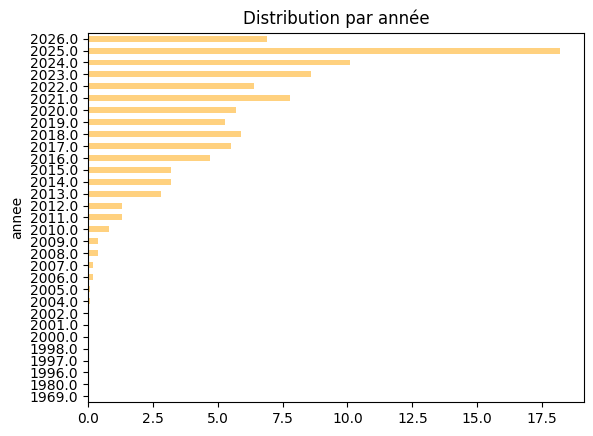

In [71]:
# Testons ensemble
# mega visu moche avec .plot()
# column et by ?
distribution.sort_index().plot(kind="barh", color="orange", alpha=0.5, title="Distribution par année")

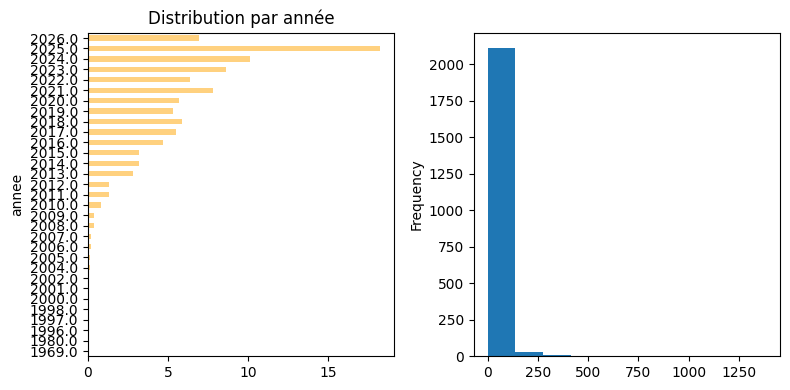

In [82]:
import matplotlib.pyplot as plt
fix,ax = plt.subplots(1,2, figsize=(8,4))
distribution.sort_index().plot(kind="barh", color="orange", alpha=0.5, title="Distribution par année", ax=ax[0])
df_ss["pertinence"].plot(kind="hist", ax=ax[1])
plt.tight_layout()
plt.savefig("plot.png")

## 2. Filtrer

### .loc et iloc

Récupérer une ligne/un élément avec .loc et .iloc

In [ ]:
# TODO : un set_index() quelque part si pas fait jusque là ?

In [ ]:
# .loc = nom des lignes et colonnes

In [ ]:
# iloc = numéro index des lignes et colonnes

### Filtrer les observations (lignes)

La plupart du temps, vous avez besoin de filtrer certaines observations (lignes) dans votre jeu de données.
- Vous vous intéressez à certains aspects particuliers de votre jeu de données (ex : seulement les articles, ceux publiés après une date, etc.).
- L'information est non pertinente et vous devez supprimer certaines données pour éviter de tirer de mauvaises conclusions (ex : les personnes qui refusent de répondre).

Vous avez donc besoin d'un moyen de filtrer les observations dans votre jeu de données.

- Les opérateurs relationnels permettent de sélectionner des observations.
- Il existe aussi des méthodes utiles pour vous aider dans cette tâche.

![](https://pandas.pydata.org/docs/_images/03_subset_rows.svg)


**Mettons qu'on ne veut travailler que sur les articles**

In [94]:
# créer un filtre/mask pour type == article
# …
# appliquer ce filtre et créer my_df_article
# …
filtre = (df_ss["pertinence"] > 10)
#df_ss[filtre]["annee"].value_counts().sort_index().plot(kind="bar")
df_ss[filtre]

,titre,annee,pertinence,abstract
id,,,,
https://openalex.org/W2159397589,Computational Social Science,2009.0,1384.055200,A field is emerging that leverages the capacit...
https://openalex.org/W2070907364,Manifesto of computational social science,2012.0,506.214630,NaN
https://openalex.org/W3081158114,Computational social science: Obstacles and op...,2020.0,447.696840,"Data sharing, research ethics, and incentives ..."
https://openalex.org/W3022499311,Computational Social Science and Sociology,2020.0,418.060900,The integration of social science with compute...
https://openalex.org/W3174174150,Integrating explanation and prediction in comp...,2021.0,415.996500,NaN
...,...,...,...,...
https://openalex.org/W4234377464,Emergence in Agent-Based Computational Social ...,2011.0,10.058286,This chapter provides a critical survey of eme...
https://openalex.org/W7119978572,On the intersection of analytical sociology an...,2025.0,10.058286,NaN
https://openalex.org/W2767131649,Review of Computational Social Science (Analyt...,2017.0,10.035590,"Review of:Alvarez, R. Michael (2016) Computati..."


## 3. Grouper / croiser des observations

### Groupby

La **fonction `groupby`** de pandas permet de regrouper les données selon les valeurs d'une ou plusieurs colonnes, puis d'appliquer des opérations statistiques (comme la moyenne, la médiane, l'écart-type, etc.) sur chaque groupe.

Cela facilite la comparaison entre différentes catégories ou groupes d'observations.

La syntaxe suit ce format :
```python
df.groupby("colonne_à_grouper")[["autre_colonne"]].operation() # .mean(), .std(), etc.
```
NB : on peut directement aggréger différentes stat avec `.agg()` :  
ex : `blablabla.agg(["median","mean"])`

In [103]:
# Grouper par année et afficher le score moyen
# …

# Afficher à la fois la mediane et la moyenne du score par année
# …

# nb : on peut utiliser tail pour afficher les dernières lignes…
df.groupby("type")["publication_year"].mean()

type
article            2019.777778
book               2019.315789
book-chapter       2020.160000
dataset            2023.788732
dissertation       2019.767857
editorial          2018.888889
letter             2019.200000
libguides          2016.111111
other              2021.655172
paratext           2018.440000
peer-review        2025.000000
preprint           2022.547684
reference-entry    2019.384615
report             2020.500000
review             2020.608696
Name: publication_year, dtype: float64

In [ ]:
# Stocker le tout dans un tableau puis faire un grah de la moyenne annuelle
# ex : mon_tableau["mean"].plot(kind="bar")


In [ ]:
# Un tableau puis faire un scatter plot moyenne vs mediane

# tableau.plot(x="mean",
#              y="median",
#              kind="scatter",
#              title="mon super titre")

### Crosstab

On peut utiliser la fonction `pd.crosstab()` pour réaliser des tableaux croisés entre deux variables (ou plus)

Pour de l'aide sur une fonction, vous pouvez faire appel à :
```python
help(pd.crosstab)
# ou
pd.crosstab?
```

In [111]:
filtre = df["publication_year"] >= 2023
round(100*pd.crosstab(df[filtre]["publication_year"],df[filtre]["type"], margins=True, normalize="index"))

type,article,book,book-chapter,dataset,dissertation,editorial,letter,other,paratext,peer-review,preprint,reference-entry,report,review
publication_year,,,,,,,,,,,,,,
2023.0,47.0,2.0,17.0,2.0,1.0,0.0,1.0,1.0,1.0,0.0,28.0,1.0,1.0,0.0
2024.0,43.0,3.0,13.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,36.0,0.0,0.0,3.0
2025.0,50.0,3.0,8.0,4.0,3.0,0.0,0.0,4.0,0.0,1.0,27.0,0.0,0.0,1.0
2026.0,45.0,1.0,4.0,25.0,1.0,0.0,0.0,9.0,0.0,0.0,13.0,0.0,1.0,0.0
All,47.0,2.0,11.0,6.0,2.0,0.0,0.0,3.0,0.0,0.0,27.0,0.0,0.0,1.0


In [ ]:
# Exemple de tableau croisé :
# limiter aux données récentes :
df_recent = my_df[my_df["annee"] >= 2020]

# et croiser type et année :
# pd.crosstab(mon_df["ma_var1"], mon_df["ma_var2"])
# …

In [ ]:
# Exemple d'un tableau croisé pourcentages en ligne
tab = pd.crosstab(
    df_recent["type"], df_recent["annee"], normalize="index", margins=True
)
tab.round(2) * 100

### Manipuler plusieurs tableaux

Réunion de deux tableaux ensemble

In [ ]:
# pd.concat([tableau_1, tableau_2], axis=1)
# Pimper les noms de colonnes avec un dictionnaire
# pd.concat…………

## 4. Recodages et modification de variables


### Créer des nouvelles variables (~ Ajout de nouvelles colonnes)

Lorsque vous recodez des variables, vous pouvez ajouter une nouvelle variable au jeu de données d'origine afin de conserver la version originale de votre variable.

![](https://pandas.pydata.org/docs/_images/05_newcolumn_1.svg)




In [115]:
df["my_new_var"] = 0
# df

In [117]:
# On peut également supprimer une colonne à l'aide de la méthode drop.
# Voyons à quoi ressemble le recoded_df si nous supprimons/dropons la variable.df.drop("my_new_var", axis=1)

# nb: axis=1 indique que nous voulons supprimer une colonne(=1), et pas une ligne(=0)

### Recodage des variables avec la méthode `.replace()`

On peut utiliser la méthode/fonction `replace` pour faciliter le recodage des variables.

In [121]:
# Essayons de recoder la variable type
# remplaçons "book-chapter" par chapitre
# blablabla.replace("ancienne valeur", "nouvelle valeur")

df["type"].replace("book-chapter", "chapitre")

0        article
1        article
2        article
3        article
4        article
          ...   
2124     article
2125     article
2126    paratext
2127    chapitre
2128    paratext
Name: type, Length: 2129, dtype: object

In [ ]:
# Passer à la fonction replace les anciennes et les nouvelles valeurs
# Je peux donc aussi plutôt utiliser un dictionnaire pour faire le recodage
my_df["type"].replace(old_labels, new_labels)

In [ ]:
# quand je suis satisfait, je "sauve" dans une nouvelle variable, ou j'écrase l'ancienne
my_df["type_recod"] = my_df["type"].replace(recode_dict)

### La méthode `.cut()` (dicrétiser des variables quanti)

La méthode/fonction `pd.cut()` nous permet de transformer une variable continue en catégories !

In [ ]:
# Regardons du côté de la variable score
# On pourrait vouloir recoder les scores en catégories (ex : quartiles)


### Version générique avec ``.apply()``

Créer une fonction qui renvoie "super pertinent" si un article il fait partie du top 10 des relevance_score

In [ ]:
# Definir une fonction

# def ma_fonction(x):
#     si condition:
#         faire des trucs avec x
#     sinon:
#         faire d'autres trucs avec x

# …

In [ ]:
# Appliquer la fonction avec apply
# df["ma_var"].apply(ma_fonction)

# …

In [133]:
def is_openscience(texte):
    """
    Renvoie vrai si contient open science
    """
    if pd.isna(texte):
        return False
    if texte.lower().count("open science")>0:
        return True
    else:
        return False
    
is_openscience("It is open ")

False

<Axes: xlabel='publication_year'>

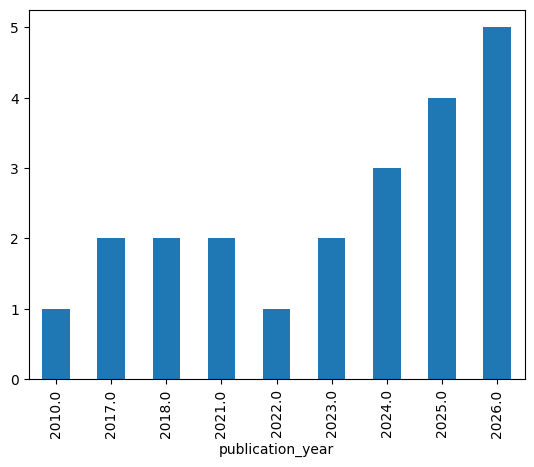

In [136]:
(df[df["abstract"].apply(is_openscience)]["publication_year"]
                 .value_counts()
                 .sort_index()
                 .plot(kind="bar"))

## Autres

In [ ]:
# isnull, isna, dropna, fillna, sample
# les modules spécialisés : dt, str, ...

In [ ]:
# Des trucs que l'on a oublié ?